Testing whether only closing affected areas in Atlantis lead to different outcomes than closing the entire model (unrealistic in real life, but could be informative since fishing might intensify in areas outside of those that have been closed)

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import warnings
import pandas as pd
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

warnings.simplefilter('ignore')

### Scenario comparison across fished groups

In [2]:
dff = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/fisheries_closed_fished.csv")

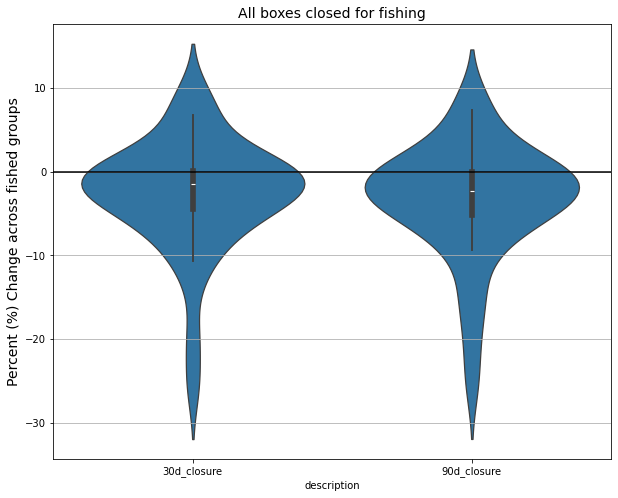

In [3]:
plt.figure(figsize=(10, 8))
plt.grid()
ax = sns.violinplot(dff, x="description", y="percent_change") 
plt.ylabel('Percent (%) Change across fished groups', fontsize = 14)
#plt.xticks(rotation=90)
plt.title('All boxes closed for fishing', fontsize = 14)
plt.axhline(0, color='k'); 

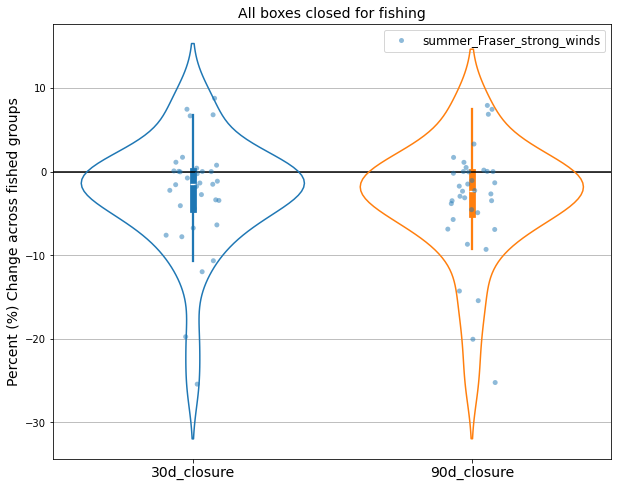

In [5]:
plt.figure(figsize=(10, 8)) 
plt.grid()
ax=sns.violinplot(dff, x="description", y="percent_change",
    hue='description', fill=False, zorder=10, legend=False) 
sns.stripplot(data=dff, x="description",
    y="percent_change", hue='sim_description', alpha=0.5, ax=ax)
plt.ylabel('Percent (%) Change across fished groups', fontsize = 14)
plt.title('All boxes closed for fishing', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xlabel(None)
plt.xticks(fontsize=14)
plt.legend(fontsize=12);

In [11]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/fisheries_closed_all.csv")

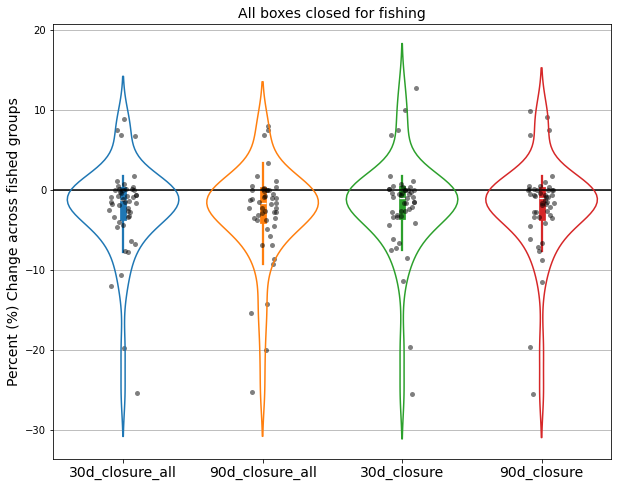

In [14]:
plt.figure(figsize=(10, 8)) 
plt.grid()
ax=sns.violinplot(df, x="description", y="percent_change",
    hue='description', fill=False, zorder=10, legend=False) 
sns.stripplot(data=df, x="description",
    y="percent_change", color='k', alpha=0.5, ax=ax)
plt.ylabel('Percent (%) Change across fished groups', fontsize = 14)
plt.title('All boxes closed for fishing', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xlabel(None)
plt.xticks(fontsize=14);

biomass change per group

In [8]:
custom_order = ['macroalgae', 'seagrass', 'benthic grazers', 'other filter feeders', 'macrobenthos',  
    'sponges', 'bivalves', 'crabs', 'dungeness crabs',
    'pelagic bacteria', 'diatoms', 'picophytoplankton', 'microzooplankton', 
    'mesozooplankton', 'squid',  
    'small pelagic',  'small demersal', 'small flatfish', 
    'benthopelagic', 'large demersal', 'large flatfish','rockfish',
    'hake','lingcod', 'pollock', 'sandlance','pacific herring', 
    'Chinook', 'Chum', 'Coho','Pink','Sockeye', 'Other salmonids',
    'Hatchery Chinook','Hatchery Coho','Hatchery Sockeye',
    'dogfish','ratfish','sixgill','skates',
    'porpoises', 'seals', 'sealions',
    'resident orcas', 'transient orcas','humpbacks',
    'seagulls','other seabirds',]

In [9]:
bio_boundaries = [9, 15, 26, 36, 40, 46]

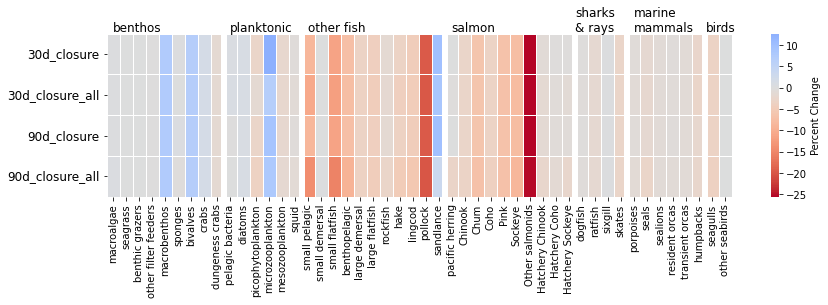

In [15]:
heatmap_data = df.pivot(index='description', columns='bio_group', values='percent_change',)
heatmap_df = heatmap_data.reindex(columns=custom_order)
plt.figure(figsize=(14, 3))
ax = sns.heatmap(
heatmap_df, 
annot=False,
fmt=".1f",
cmap="coolwarm_r", 
center=0, #vmin=-5, vmax=5,
linewidths=0.5, 
#linecolor='gray',
cbar_kws={'label': 'Percent Change'}
)
plt.xlabel(None)
plt.ylabel(None)
for x in bio_boundaries:
    ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=6)
#plt.title('Change in biomass compared to no closures')
#plt.title(groups.scenarios[str(scenario_label)])
y_position = -0.05
font_size = 12
plt.text(0.5, y_position, 'benthos', color='k', size=font_size,)
plt.text(9.5, y_position, 'planktonic', color='k', size=font_size,)
plt.text(15.5, y_position, 'other fish', color='k', size=font_size,)
plt.text(26.5, y_position, 'salmon', color='k', size=font_size,)
plt.text(36, y_position, 'sharks\n& rays', color='k', size=font_size,)
plt.text(40.5, y_position, 'marine\nmammals', color='k', size=font_size,)
plt.text(46, y_position, 'birds', color='k', size=font_size,)
plt.yticks(rotation=0,size=font_size,);